In this notebook, I will try an implementation of DeepBar - a.k.a Gaussianized Bridge Sampling as far as I can tell.

This implementation will borrow from the POCOMC code base.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.distributions as td
import numpy as np
from scipy.special import logsumexp
from scipy.optimize import root_scalar

# Original function in POCOMC

In [3]:
    def bridge_sampling(self, maxiter=2000, rtol=1e-13, xtol=1e-13, thin=1):
        r"""
            Bridge Sampling estimator for the log model evidence.
            This implements the Gaussianised Bridge Sampling 
            algorithm https://arxiv.org/abs/1912.06073 which
            utilises a normalising flow as the auxiliary distribution.
        Parameters
        ----------
        maxiter : ``int``
            Maximum number of iterations of root-finding procedure.
        rtol : ``float``
            Relative numerical tolerance of root-finding procedure.
        xtol : ``float``
            Absolute numerical tolerance of root-finding procedure.
        thin : ``int``
            Thin the samples by a integer factor. Default is ``thin=1``
            (no thinning).
        Returns
        -------
        logr : ``float``
            Estimate of log model evidence.
        logr_err : ``float``
            Estimate of the 1-sigma uncertainty of the log model evidence.
        """

        x = self.results.get("samples")[::thin]
        l = self.results.get("loglikelihood")[::thin]
        p = self.results.get("logprior")[::thin]
        ess = self.ess

        N1 = len(x)
        N2 = len(x)

        s1 = N1 / (N1+N2)
        s2 = N2 / (N1+N2)

        theta_prop = torch.randn((N2, self.n_dim))
        u_prop, log_abs_det_jac = self.flow.inverse(theta_prop)
        logg_i = torch.sum(self.flow.flow.base_dist.log_prob(theta_prop) - log_abs_det_jac, dim=1)
        u_prop = torch_to_numpy(u_prop)
        x_prop, J_prop = self.scaler.inverse(u_prop)
        logg_i = torch_to_numpy(logg_i) - J_prop

        u = self.scaler.forward(x)
        x, J = self.scaler.inverse(u)
        logg_j = torch_to_numpy(self.flow.logprob(numpy_to_torch(u))) - J

        log_prior_tmp = self._log_prior(x_prop)
        finite_prior_mask = np.isfinite(log_prior_tmp)
        log_like_tmp = np.full((len(x_prop), ), -np.inf)
        log_like_tmp[finite_prior_mask] = self._log_like(x_prop[finite_prior_mask])
        logp_i = log_prior_tmp + log_like_tmp
        logp_j = p + l

        _a = logg_j - logp_j - np.log(N1 / N2)
        _b = logp_i - logg_i + np.log(N1 / N2)

        def score(logr):
            _c = logsumexp(logr + _a - logsumexp(np.array((logr + _a,
                        np.zeros_like(_a))), axis=0))
            _d = logsumexp(-logr + _b - logsumexp(np.array((-logr + _b,
                        np.zeros_like(_b))), axis=0))
            return _c - _d

        logr = root_scalar(score, x0=0, x1=5, maxiter=maxiter, rtol=rtol, xtol=xtol).root

        # Uncertainty
        f1 = np.exp(logp_i - logr - logsumexp(np.array((logp_i - logr +
                    np.log(s1), logg_i + np.log(s2))), axis=0))
        f2 = np.exp(logg_j - logsumexp(np.array((logp_j - logr +
                    np.log(s1), logg_j + np.log(s2))), axis=0))
        re2_q = np.var(f1) / np.mean(f1)**2 / N2

        tau = 1.0 / ess
        re2_p = tau * np.var(f2) / np.mean(f2)**2 / N1
        logr_err = (re2_p + re2_q)**0.5

        return logr, logr_err

# Using the custom MOG class to run toy tests

In [4]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)

sep = 2.
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
shift_means = [torch.tensor([-sep*0.8, 0])] #, torch.tensor([sep, 0])]

target = MoG(means, covars)
prop = MoG(shift_means, covars)

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343668887/work/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


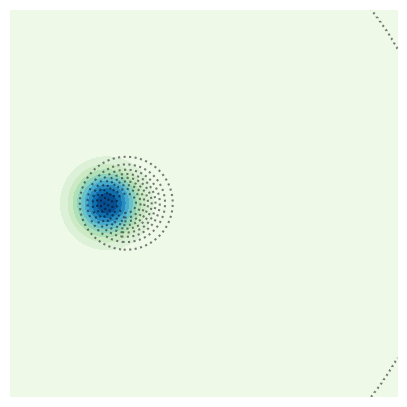

In [5]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

# Starting to adapt implementation

In [10]:
maxiter=2000
rtol=1e-13
xtol=1e-13
thin=1
ess=1 # that is to evaluate the error on the
        
n_mcmc = 1000
n_prop = 1000
dim = 2

xs = target.sample(n_mcmc)[::thin]
xs_prop = prop.sample(n_prop)[::thin]

n_mcmc = len(xs)
n_prop = len(xs_prop)

logprop_prop = prop.log_prob(xs_prop).numpy() 
logprop_mc = prop.log_prob(xs).numpy() 
logtgt_prop = target.log_prob(xs_prop).numpy() + np.log(2)
logtgt_mc = target.log_prob(xs).numpy() + np.log(2)

_a = logprop_mc - logtgt_mc - np.log(n_mcmc / n_prop)
_b = logtgt_prop - logprop_prop + np.log(n_mcmc / n_prop)

def score(logr):
    _c = logsumexp(logr + _a - logsumexp(np.array((logr + _a,
                np.zeros_like(_a))), axis=0))
    _d = logsumexp(-logr + _b - logsumexp(np.array((-logr + _b,
                np.zeros_like(_b))), axis=0))
    return _c - _d

logr = root_scalar(score, x0=0, x1=5, maxiter=maxiter, rtol=rtol, xtol=xtol).root

# Uncertainty
s1 = n_mcmc / (n_mcmc + n_prop)
s2 = n_prop / (n_mcmc + n_prop)

f1 = np.exp(logtgt_prop - logr - logsumexp(np.array((logtgt_prop - logr +
            np.log(s1), logprop_prop + np.log(s2))), axis=0))
f2 = np.exp(logprop_mc - logsumexp(np.array((logtgt_mc - logr +
            np.log(s1), logprop_mc + np.log(s2))), axis=0))
re2_q = np.var(f1) / np.mean(f1)**2 / n_prop

tau = 1.0 / ess
re2_p = tau * np.var(f2) / np.mean(f2)**2 / n_mcmc
logr_err = (re2_p + re2_q)**0.5

np.exp(logr), np.exp(logr_err)

(2.0191273117647675, 1.0206261637332967)

In [16]:
prop.weights

tensor([1.])

# One state implementation

In [17]:
def compute_BAR(xs, target_log_prob, prop, n_prop=None, 
        maxiter=2000, rtol=1e-13, xtol=1e-13, thin=1, ess=1
        ):
    r"""
    Bridge Sampling/Bennett Acceptance Ratio estimator for the log partition of target.
    https://arxiv.org/abs/1912.06073, pocomc, deepbar

    Parameters
    ----------
    xs : torch.Tensor
        Samples from the target distribution.
    target_log_prob : callable
        Log probability of the target distribution.
    prop : Flow or torch.distributions.Distribution
        Proposal distribution, with .sample and .log_prob methods.
    n_prop : int, optional
        Number of samples from the proposal distribution. If None, use the same number as the target.
    maxiter : ``int``
        Maximum number of iterations of root-finding procedure.
    rtol : ``float``
        Relative numerical tolerance of root-finding procedure.
    xtol : ``float``
        Absolute numerical tolerance of root-finding procedure.
    thin : ``int``
        Thin the samples by a integer factor. Default is ``thin=1``
        (no thinning).
    ess : ``float``
        Effective sample size of xs samples to estimate errors.
    
    Returns
    -------
    logr : ``float``
        Estimate of log partition pf target.
    logr_err : ``float``
        Estimate of the 1-sigma uncertainty of the log partition pf target.
    """

    if n_prop is None:
        n_prop = len(xs)
    xs_prop = prop.sample(n_prop)

    xs = xs[:thin]

    n_mcmc = len(xs)
    n_prop = len(xs_prop)

    logprop_prop = prop.log_prob(xs_prop).numpy() 
    logprop_mc = prop.log_prob(xs).numpy() 
    logtgt_prop = target_log_prob(xs_prop).numpy() #+ np.log(2)
    logtgt_mc = target_log_prob(xs).numpy() #+ np.log(2)

    _a = logprop_mc - logtgt_mc - np.log(n_mcmc / n_prop)
    _b = logtgt_prop - logprop_prop + np.log(n_mcmc / n_prop)

    def score(logr):
        _c = logsumexp(logr + _a - logsumexp(np.array((logr + _a,
                    np.zeros_like(_a))), axis=0))
        _d = logsumexp(-logr + _b - logsumexp(np.array((-logr + _b,
                    np.zeros_like(_b))), axis=0))
        return _c - _d

    logr = root_scalar(score, x0=0, x1=5, maxiter=maxiter, rtol=rtol, xtol=xtol).root

    # Uncertainty
    s1 = n_mcmc / (n_mcmc + n_prop)
    s2 = n_prop / (n_mcmc + n_prop)

    f1 = np.exp(logtgt_prop - logr - logsumexp(np.array((logtgt_prop - logr +
                np.log(s1), logprop_prop + np.log(s2))), axis=0))
    f2 = np.exp(logprop_mc - logsumexp(np.array((logtgt_mc - logr +
                np.log(s1), logprop_mc + np.log(s2))), axis=0))
    re2_q = np.var(f1) / np.mean(f1)**2 / n_prop

    tau = 1.0 / ess
    re2_p = tau * np.var(f2) / np.mean(f2)**2 / n_mcmc
    logr_err = (re2_p + re2_q)**0.5

    return logr, logr_err
    

## 1.1 Shifting the overlap

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/torch/distributions/distribution.py:173: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


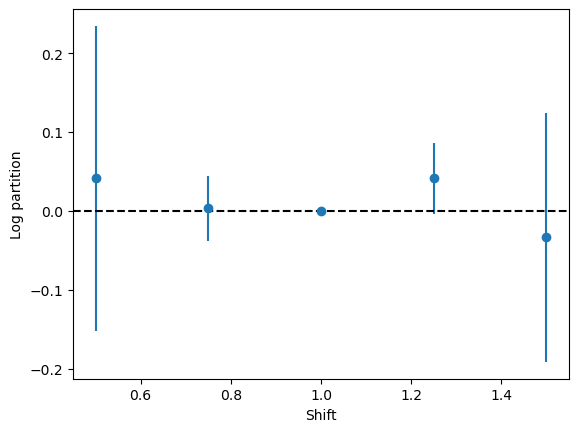

<Figure size 640x480 with 0 Axes>

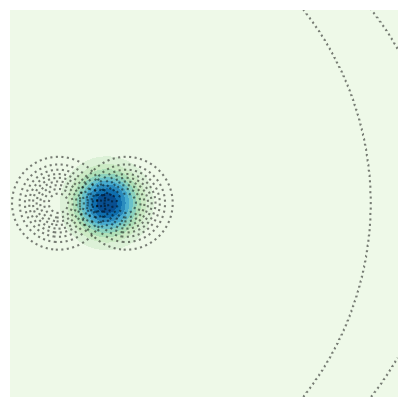

In [18]:
sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]

shifts = torch.linspace(0.5, 1.5, 5)
logrs = []
logr_errs = []

xs = target.sample(10000)

for shift in shifts:
    shift_means = [torch.tensor([-sep * shift, 0])] #, torch.tensor([sep, 0])]

    target = MoG(means, covars)
    prop = MoG(shift_means, covars)

    logr, logr_err = compute_BAR(xs, target.log_prob, prop, n_prop=1000, ess=ess)

    logrs.append(logr)
    logr_errs.append(logr_err)

plt.figure(1)
plt.errorbar(shifts, logrs, yerr=logr_errs, fmt='o')
plt.axhline(0, color='k', linestyle='--', label='True')
plt.xlabel('Shift')
plt.ylabel('Log partition')
plt.show(block=False)

plt.figure(2)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims)


## 1.2 Shifting the value of the partition

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.770782063204024e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.7881393432617188e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1361074392368664e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.2885662254168437e-07 reached.
  warnings.warn(msg, RuntimeWarning)


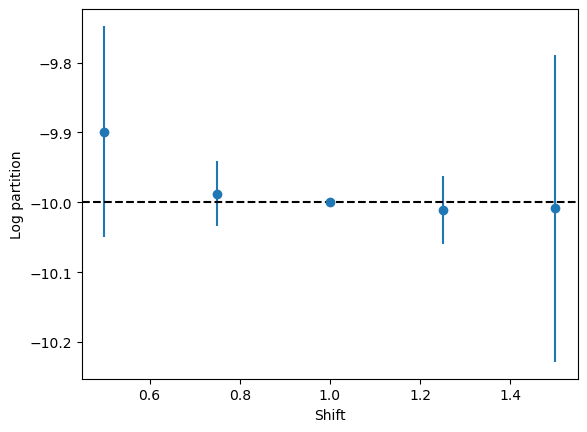

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.6190756824130403e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.1581504200108839e-07 reached.
  warnings.warn(msg, RuntimeWarning)


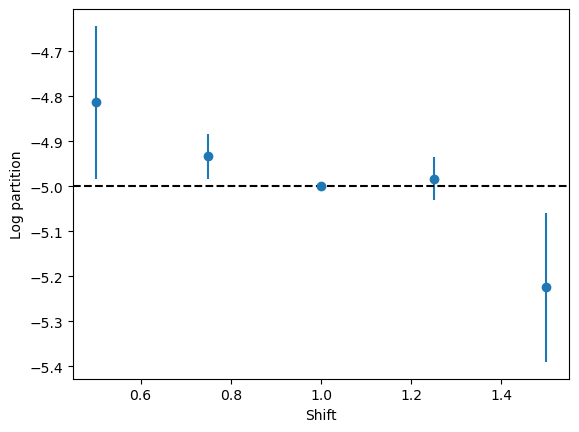

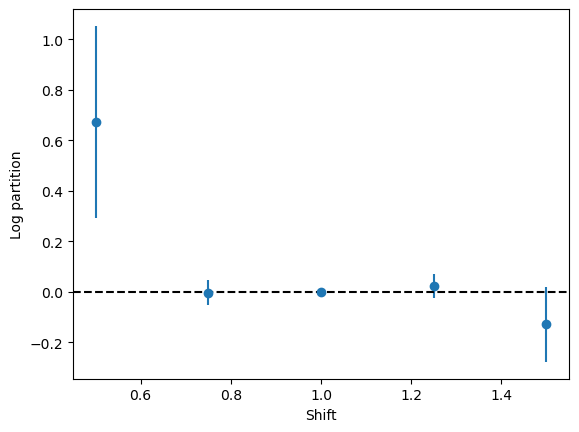

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.0015514728678454e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.962835889609778e-08 reached.
  warnings.warn(msg, RuntimeWarning)


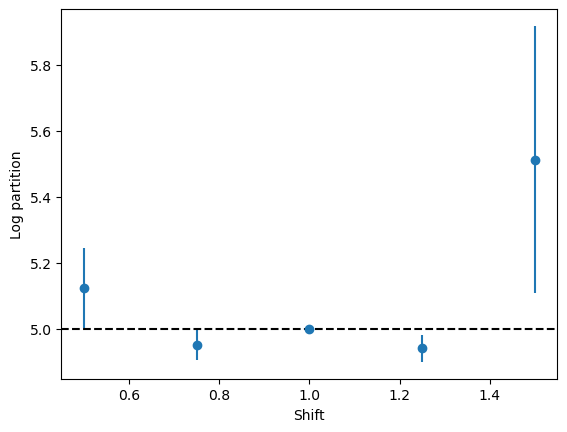

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 5.913838485582801e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.5097031180744125e-08 reached.
  warnings.warn(msg, RuntimeWarning)


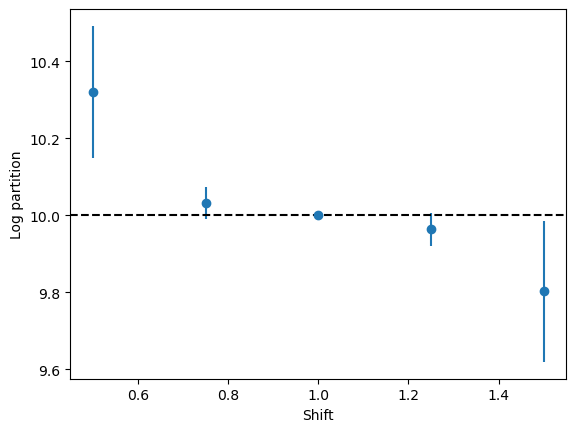

In [19]:
sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]

shifts = torch.linspace(0.5, 1.5, 5)
log_partition_shifts = torch.linspace(-10, 10, 5)

xs = target.sample(10000)
for log_partition_shift in log_partition_shifts:
    target = MoG(means, covars)
    target_log_prob = lambda x: target.log_prob(x) + log_partition_shift

    logrs = []
    logr_errs = []
    for shift in shifts:
        shift_means = [torch.tensor([-sep * shift, 0])] #, torch.tensor([sep, 0])]

        
        prop = MoG(shift_means, covars)

        logr, logr_err = compute_BAR(xs, target_log_prob, prop, n_prop=1000, ess=ess)

        logrs.append(logr)
        logr_errs.append(logr_err)

    plt.figure()
    plt.errorbar(shifts, logrs, yerr=logr_errs, fmt='o')
    plt.axhline(log_partition_shift, color='k', linestyle='--', label='True')
    plt.xlabel('Shift')
    plt.ylabel('Log partition')
    plt.show(block=False)



# 1.3 Under/Overdispersed

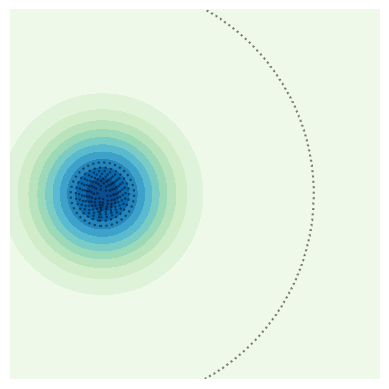

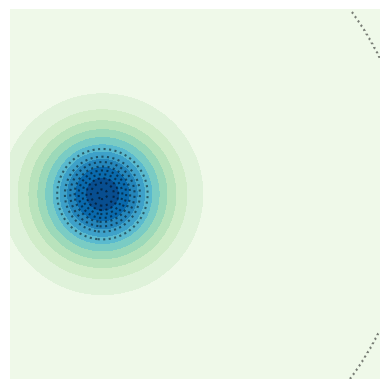

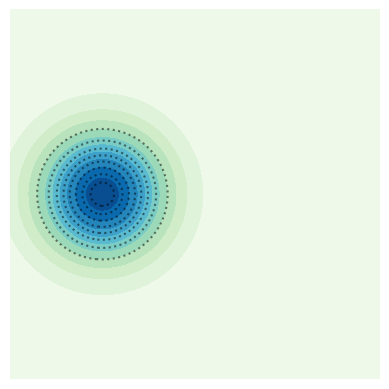

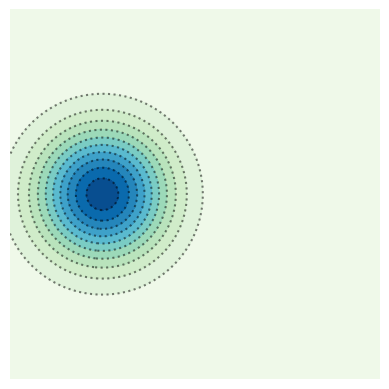

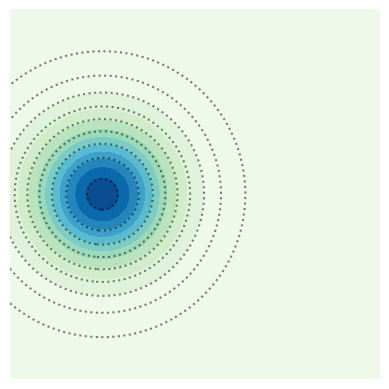

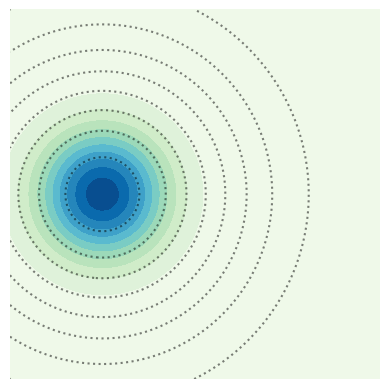

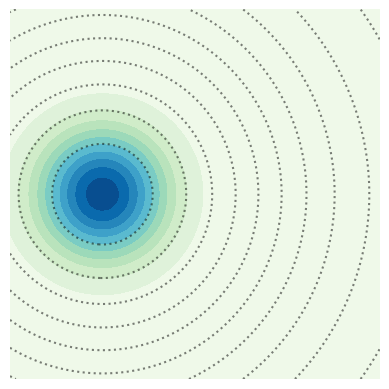

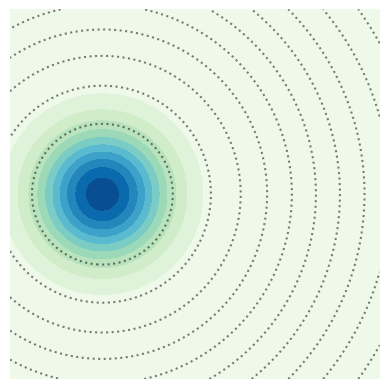

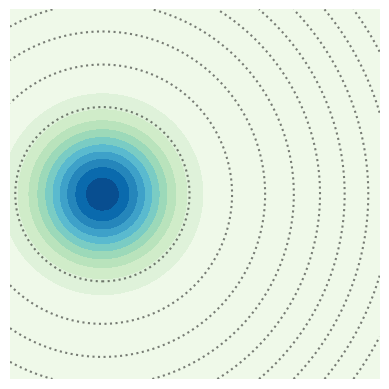

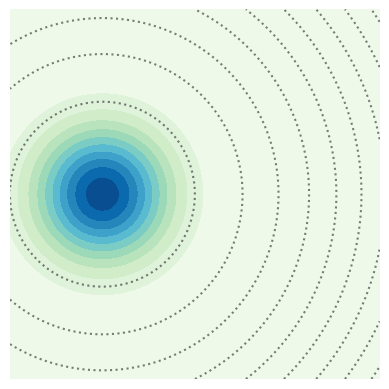

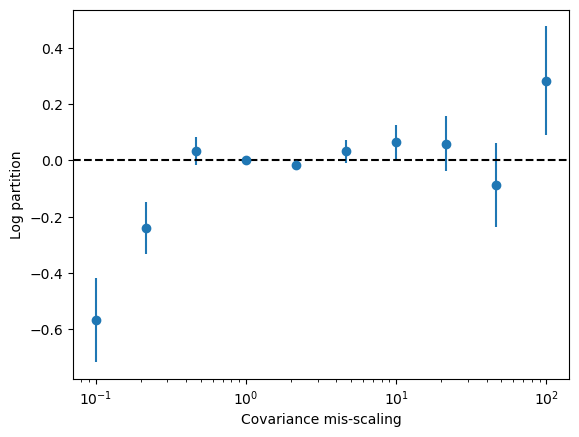

In [20]:
sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [torch.eye(2)] #,  2e-2 * torch.eye(2)]

cov_shifts = torch.logspace(-1, 2, 10)
logrs = []
logr_errs = []

xs = target.sample(10000)

for cov_shift in cov_shifts:
    shift_covars = [cov_shift * torch.eye(2)] #, torch.tensor([sep, 0])]

    target = MoG(means, covars)
    prop = MoG(means, shift_covars)

    logr, logr_err = compute_BAR(xs, target.log_prob, prop, n_prop=1000, ess=ess)

    logrs.append(logr)
    logr_errs.append(logr_err)

    plt.figure()
    ax = plt.subplot(111)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims)

plt.figure()
plt.subplot(111)
plt.errorbar(cov_shifts, logrs, yerr=logr_errs, fmt='o')
plt.axhline(0, color='k', linestyle='--', label='True')
plt.xlabel('Covariance mis-scaling')
plt.ylabel('Log partition')
plt.xscale('log')
plt.show(block=False)



## 1.4 Comparing BAR with thermodynamic integration / Jarzinsky

In [23]:
def compute_TEP(logprob_target, prop, n_prop=1000):
    """Compute the targeted free energy perturbation estimate 
     of the log-partition function for a single step proposal.

    Z / Z_prop = < e^(-logprob_target + log_prob_prop) >_prop 
    
    Args:
        logprob_target: Log-probability of the target distribution.
        prop: proposal distribution with log_prob and sample method
        n_prop: Number of samples to draw from the proposal distribution.
        
    Returns:
        logr: The log-partition function estimate.
        logr_err: The error on the log-partition function estimate.
    """

    xs_prop = prop.sample(n_prop)

    print(logprob_target(xs_prop).shape)

    logr = torch.logsumexp(logprob_target(xs_prop) - prop.log_prob(xs_prop), dim=0) 
    logr -= np.log(n_prop)
    logr_err = torch.std(torch.exp(logprob_target(xs_prop) - prop.log_prob(xs_prop)))
    logr_err /= np.sqrt(n_prop)
    logr_err /= torch.exp(logr)
    return logr, logr_err


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -2.2762348869144466e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.0542035661087468e-07 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
torch.Size([1000])


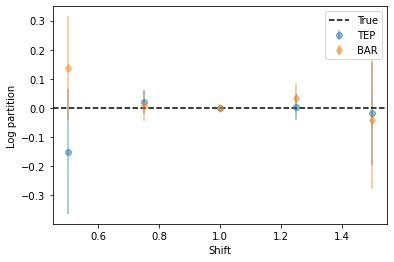

<Figure size 432x288 with 0 Axes>

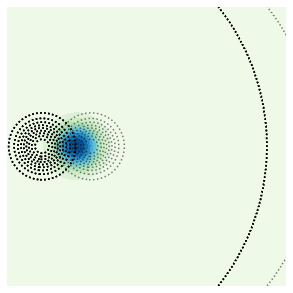

In [29]:
sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]

shifts = torch.linspace(0.5, 1.5, 5)
logrs = []
logr_errs = []
logrs_bar = []
logr_errs_bar = []

xs = target.sample(10000)

for shift in shifts:
    shift_means = [torch.tensor([-sep * shift, 0])] #, torch.tensor([sep, 0])]

    target = MoG(means, covars)
    prop = MoG(shift_means, covars)

    logr, logr_err = compute_TEP(target.log_prob, prop, n_prop=1000)
    logrs.append(logr)
    logr_errs.append(logr_err)

    xs = target.sample(1000)
    logr_bar, logr_bar_err = compute_BAR(xs, target.log_prob, prop, n_prop=1000, ess=ess)
    logrs_bar.append(logr_bar)
    logr_errs_bar.append(logr_bar_err)
    

plt.figure(1)
plt.errorbar(shifts, logrs, yerr=logr_errs, fmt='o', label='TEP', alpha=0.5)
plt.errorbar(shifts, logrs_bar, yerr=logr_errs_bar, fmt='d', label='BAR', alpha=0.5)
plt.axhline(0, color='k', linestyle='--', label='True')
plt.xlabel('Shift')
plt.ylabel('Log partition')
plt.legend()
plt.show(block=False)

plt.figure(2)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])
torch.Size([10000])


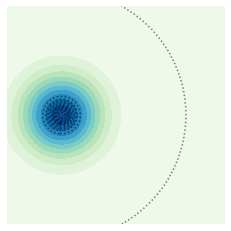

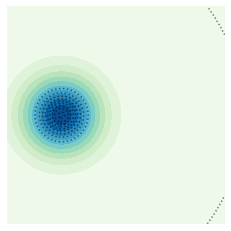

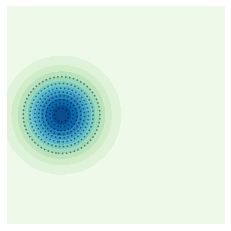

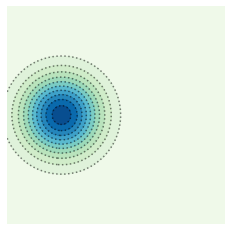

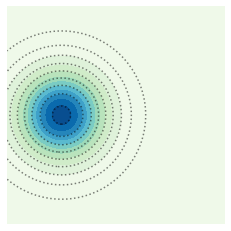

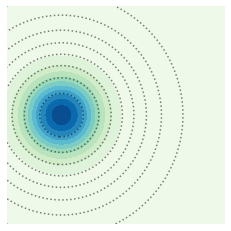

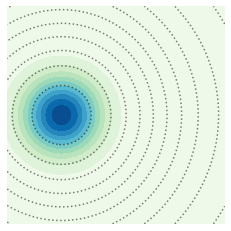

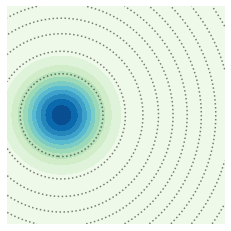

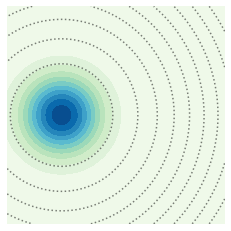

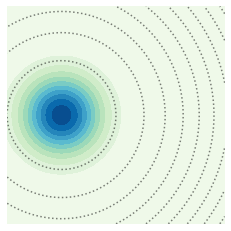

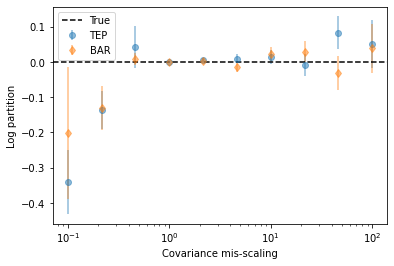

In [31]:
sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [torch.eye(2)] #,  2e-2 * torch.eye(2)]

cov_shifts = torch.logspace(-1, 2, 10)
logrs = []
logr_errs = []

logrs_bar = []
logr_errs_bar = []

xs = target.sample(10000)
n_prop = 10000

for cov_shift in cov_shifts:
    shift_covars = [cov_shift * torch.eye(2)] #, torch.tensor([sep, 0])]

    target = MoG(means, covars)
    prop = MoG(means, shift_covars)

    logr, logr_err = compute_TEP(target.log_prob, prop, n_prop)
    logrs.append(logr)
    logr_errs.append(logr_err)


    logr, logr_err = compute_BAR(xs, target.log_prob, prop, n_prop, ess=ess)
    logrs_bar.append(logr)
    logr_errs_bar.append(logr_err)
    
    plt.figure()
    ax = plt.subplot(111)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims)

plt.figure()
plt.subplot(111)
plt.errorbar(cov_shifts, logrs, yerr=logr_errs, fmt='o', alpha=0.5, label='TEP')
plt.errorbar(cov_shifts, logrs_bar, yerr=logr_errs_bar, fmt='d', alpha=0.5, label='BAR')
plt.axhline(0, color='k', linestyle='--', label='True')
plt.xlabel('Covariance mis-scaling')
plt.ylabel('Log partition')
plt.xscale('log')
plt.legend()
plt.show(block=False)



There does not seem to be a clear winner by eye -> could add a plot of the variance and the actual error as a function of the shift to try to systematize

# 2 - Comparing two states 

Two modes with equal weights but different covariances - proposing with perfect proposal just missing the weights

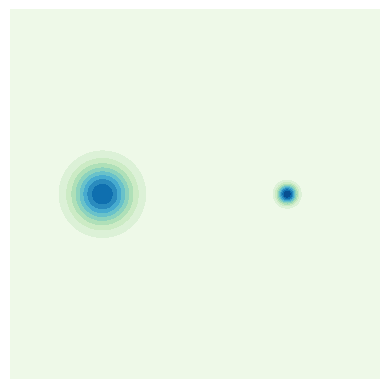

In [21]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-2 * torch.eye(2)]
weights = [0.9, 0.1]
target = MoG(means, covars, weights=weights)

plt.figure()
ax = plt.subplot(111)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims)

## 2.2 Using samples from either of the target modes

expected ratio is 9.00e+00. Result 9.00e+00, errors: [3.169151499120794e-09, 4.286150072807754e-09]


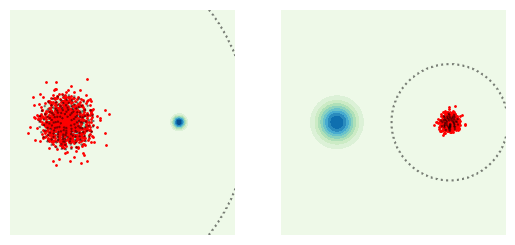

In [22]:
# shifts = torch.linspace(0.5, 1.5, 5)
logrs = []
logr_errs = []

n_sample = 1000


# for shift in shifts:
shift = 1.0
for mode in range(len(means)):

    # unimodal proposal oblivious to the weight
    shift_means = [torch.tensor([means[mode][0] * shift, 0]),]
    prop = MoG(shift_means, [covars[mode]])

    xs = target.normal_distribs[mode].sample((n_sample,))
    logr, logr_err = compute_BAR(xs, target.log_prob, prop, n_prop=None, ess=ess)

    logrs.append(logr)
    logr_errs.append(logr_err)
    
    ax = plt.subplot(1, 2, mode + 1)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob,
             prop_log_prob=prop.log_prob, lims=lims)
    ax.scatter(xs[:, 0], xs[:, 1], color='r', s=1)

print('expected ratio is {:0.2e}. Result {:0.2e}, errors:'.format(
    weights[0]/weights[1],
    np.exp(logrs[0]-logrs[1])), 
    logr_errs)

## 2.2 Using samples from the target in making the estimation -> will not work!

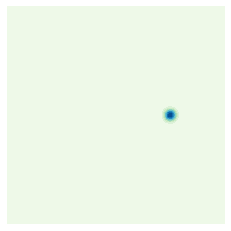

In [125]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-2 * torch.eye(2)]
weights = [0.5, 0.5]
target = MoG(means, covars, weights=weights)

plt.figure()
ax = plt.subplot(111)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims)

[0.5, 0.5]
expected ratio is 1.00e+00. Result 1.00e+00, errors: [2.803953562605786e-09, 2.4218857043664942e-09]
[tensor([-2.,  0.]), tensor([2., 0.])]


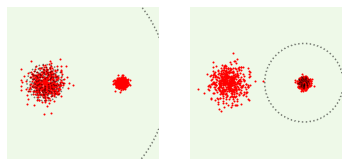

In [138]:
# shifts = torch.linspace(0.5, 1.5, 5)
logrs = []
logr_errs = []

n_sample = 1000

# for shift in shifts:
shift = 1.0
for mode in range(len(means)):

    # unimodal proposal oblivious to the weight
    shift_means = [torch.tensor([means[mode][0] * shift, 0]),]
    prop = MoG(shift_means, [covars[mode]])

    xs = target.sample(n_sample,)
    logr, logr_err = compute_BAR(xs, target.log_prob, prop, n_prop=None, ess=ess)

    logrs.append(logr)
    logr_errs.append(logr_err)
    
    ax = plt.subplot(1, 2, mode + 1)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob,
             prop_log_prob=prop.log_prob, lims=lims)
    ax.scatter(xs[:, 0], xs[:, 1], color='r', s=1)

print(weights)

print('expected ratio is {:0.2e}. Result {:0.2e}, errors:'.format(
    weights[0]/weights[1],
    np.exp(logrs[0]-logrs[1])), 
    logr_errs)

print(means)

## Computing ratios of partition fucntions

In [142]:
def deepBAR_logratio(xs, cs, target_log_prob, mix_prop, n_prop=None):
    """Compute the log ratio of the deepBAR estimator.
    Output: 
        - logr: beta * F_0 - beta * F_1 = log(weight_0 / weight(1))
    """
    logrs = []
    logr_errs = []

    for mode in range(2):

        prop = mix_prop[mode]

        xs_mode = xs[cs == mode]
        
        # TODO: plugin true ESS to compute the error
        raise Warning("Error estimation misses ESS estimation")
        ess = 1

        logr, logr_err = compute_BAR(xs_mode, target_log_prob, prop, n_prop=n_prop,
                                     ess=ess)

        logrs.append(logr)
        logr_errs.append(logr_err)
        
    return  logrs[0] - logrs[1], logr_errs[0] + logr_errs[1] 
